# OT4ML logo by optimal transport maps

This notebook generates logo candidates inspired by the POT logo: red source atoms, blue target atoms and black transport segments arranged inside the block letters `OT4ML`.

The same source and target clouds are matched with several costs: $W_2$, $W_1$, $W_\infty$ and anisotropic Euclidean metrics.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, SVG, display

from ot4ml_logo import METRICS, OUTPUT_DIR, draw_logo, generate_all, ot4ml_points, render_sheet, render_variant, solve_assignment

OUTPUT_DIR.mkdir(exist_ok=True)

## Source and target atoms

Each horizontal stroke in a seven-row block glyph contributes one red source atom and one blue target atom. The OT assignment recomputes which red atom is sent to which blue atom for each ground metric.

number of atoms: 40


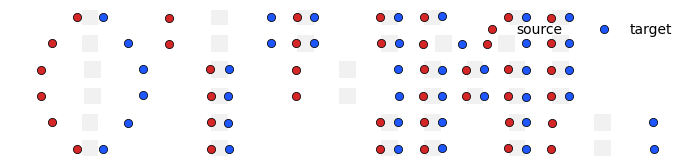

In [2]:
source, target, cells = ot4ml_points(seed=4)
print(f"number of atoms: {len(source)}")

fig, ax = plt.subplots(figsize=(8.7, 2.25))
ax.scatter(cells[:, 0], cells[:, 1], s=145, marker="s", c="#f1f1f1", edgecolors="none", zorder=0)
ax.scatter(source[:, 0], source[:, 1], s=35, c="#d62728", edgecolors="black", linewidths=0.55, zorder=2, label="source")
ax.scatter(target[:, 0], target[:, 1], s=35, c="#1f57ff", edgecolors="black", linewidths=0.55, zorder=3, label="target")
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="upper right", frameon=False, ncols=2)
plt.show()

## Metric sweep

The helper uses a linear assignment for $W_2$, $W_1$ and anisotropic $L_2$. For $W_\infty$, it solves the bottleneck assignment: first minimize the longest transported edge, then tie-break with a tiny Euclidean objective.

In [3]:
generated = {}
for spec in METRICS:
    svg_path, png_path, assignment = render_variant(spec, source, target, output_dir=OUTPUT_DIR)
    generated[spec.key] = (svg_path, png_path)
    print(f"{spec.key:>10}: {svg_path.name}, {png_path.name}")

sheet_svg, sheet_png = render_sheet(source, target, METRICS, output_dir=OUTPUT_DIR)
print(f"metric sheet: {sheet_svg.name}, {sheet_png.name}")

        w2: ot4ml_logo_w2.svg, ot4ml_logo_w2.png
        w1: ot4ml_logo_w1.svg, ot4ml_logo_w1.png
      winf: ot4ml_logo_winf.svg, ot4ml_logo_winf.png


  aniso_x4: ot4ml_logo_aniso_x4.svg, ot4ml_logo_aniso_x4.png
  aniso_y4: ot4ml_logo_aniso_y4.svg, ot4ml_logo_aniso_y4.png


aniso_diag: ot4ml_logo_aniso_diag.svg, ot4ml_logo_aniso_diag.png


metric sheet: ot4ml_logo_metric_sheet.svg, ot4ml_logo_metric_sheet.png


## Recommended logo: anisotropic $L_2$ $(4,1)$

The horizontal anisotropy favors the long transport rays that make the letters read cleanly, while the remaining rows below compare alternative metrics.

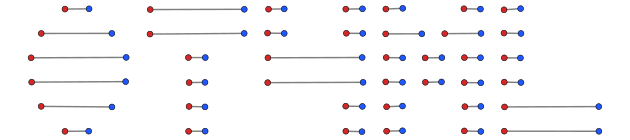

In [4]:
display(SVG(filename=str(generated["aniso_x4"][0])))

## Comparison across metrics

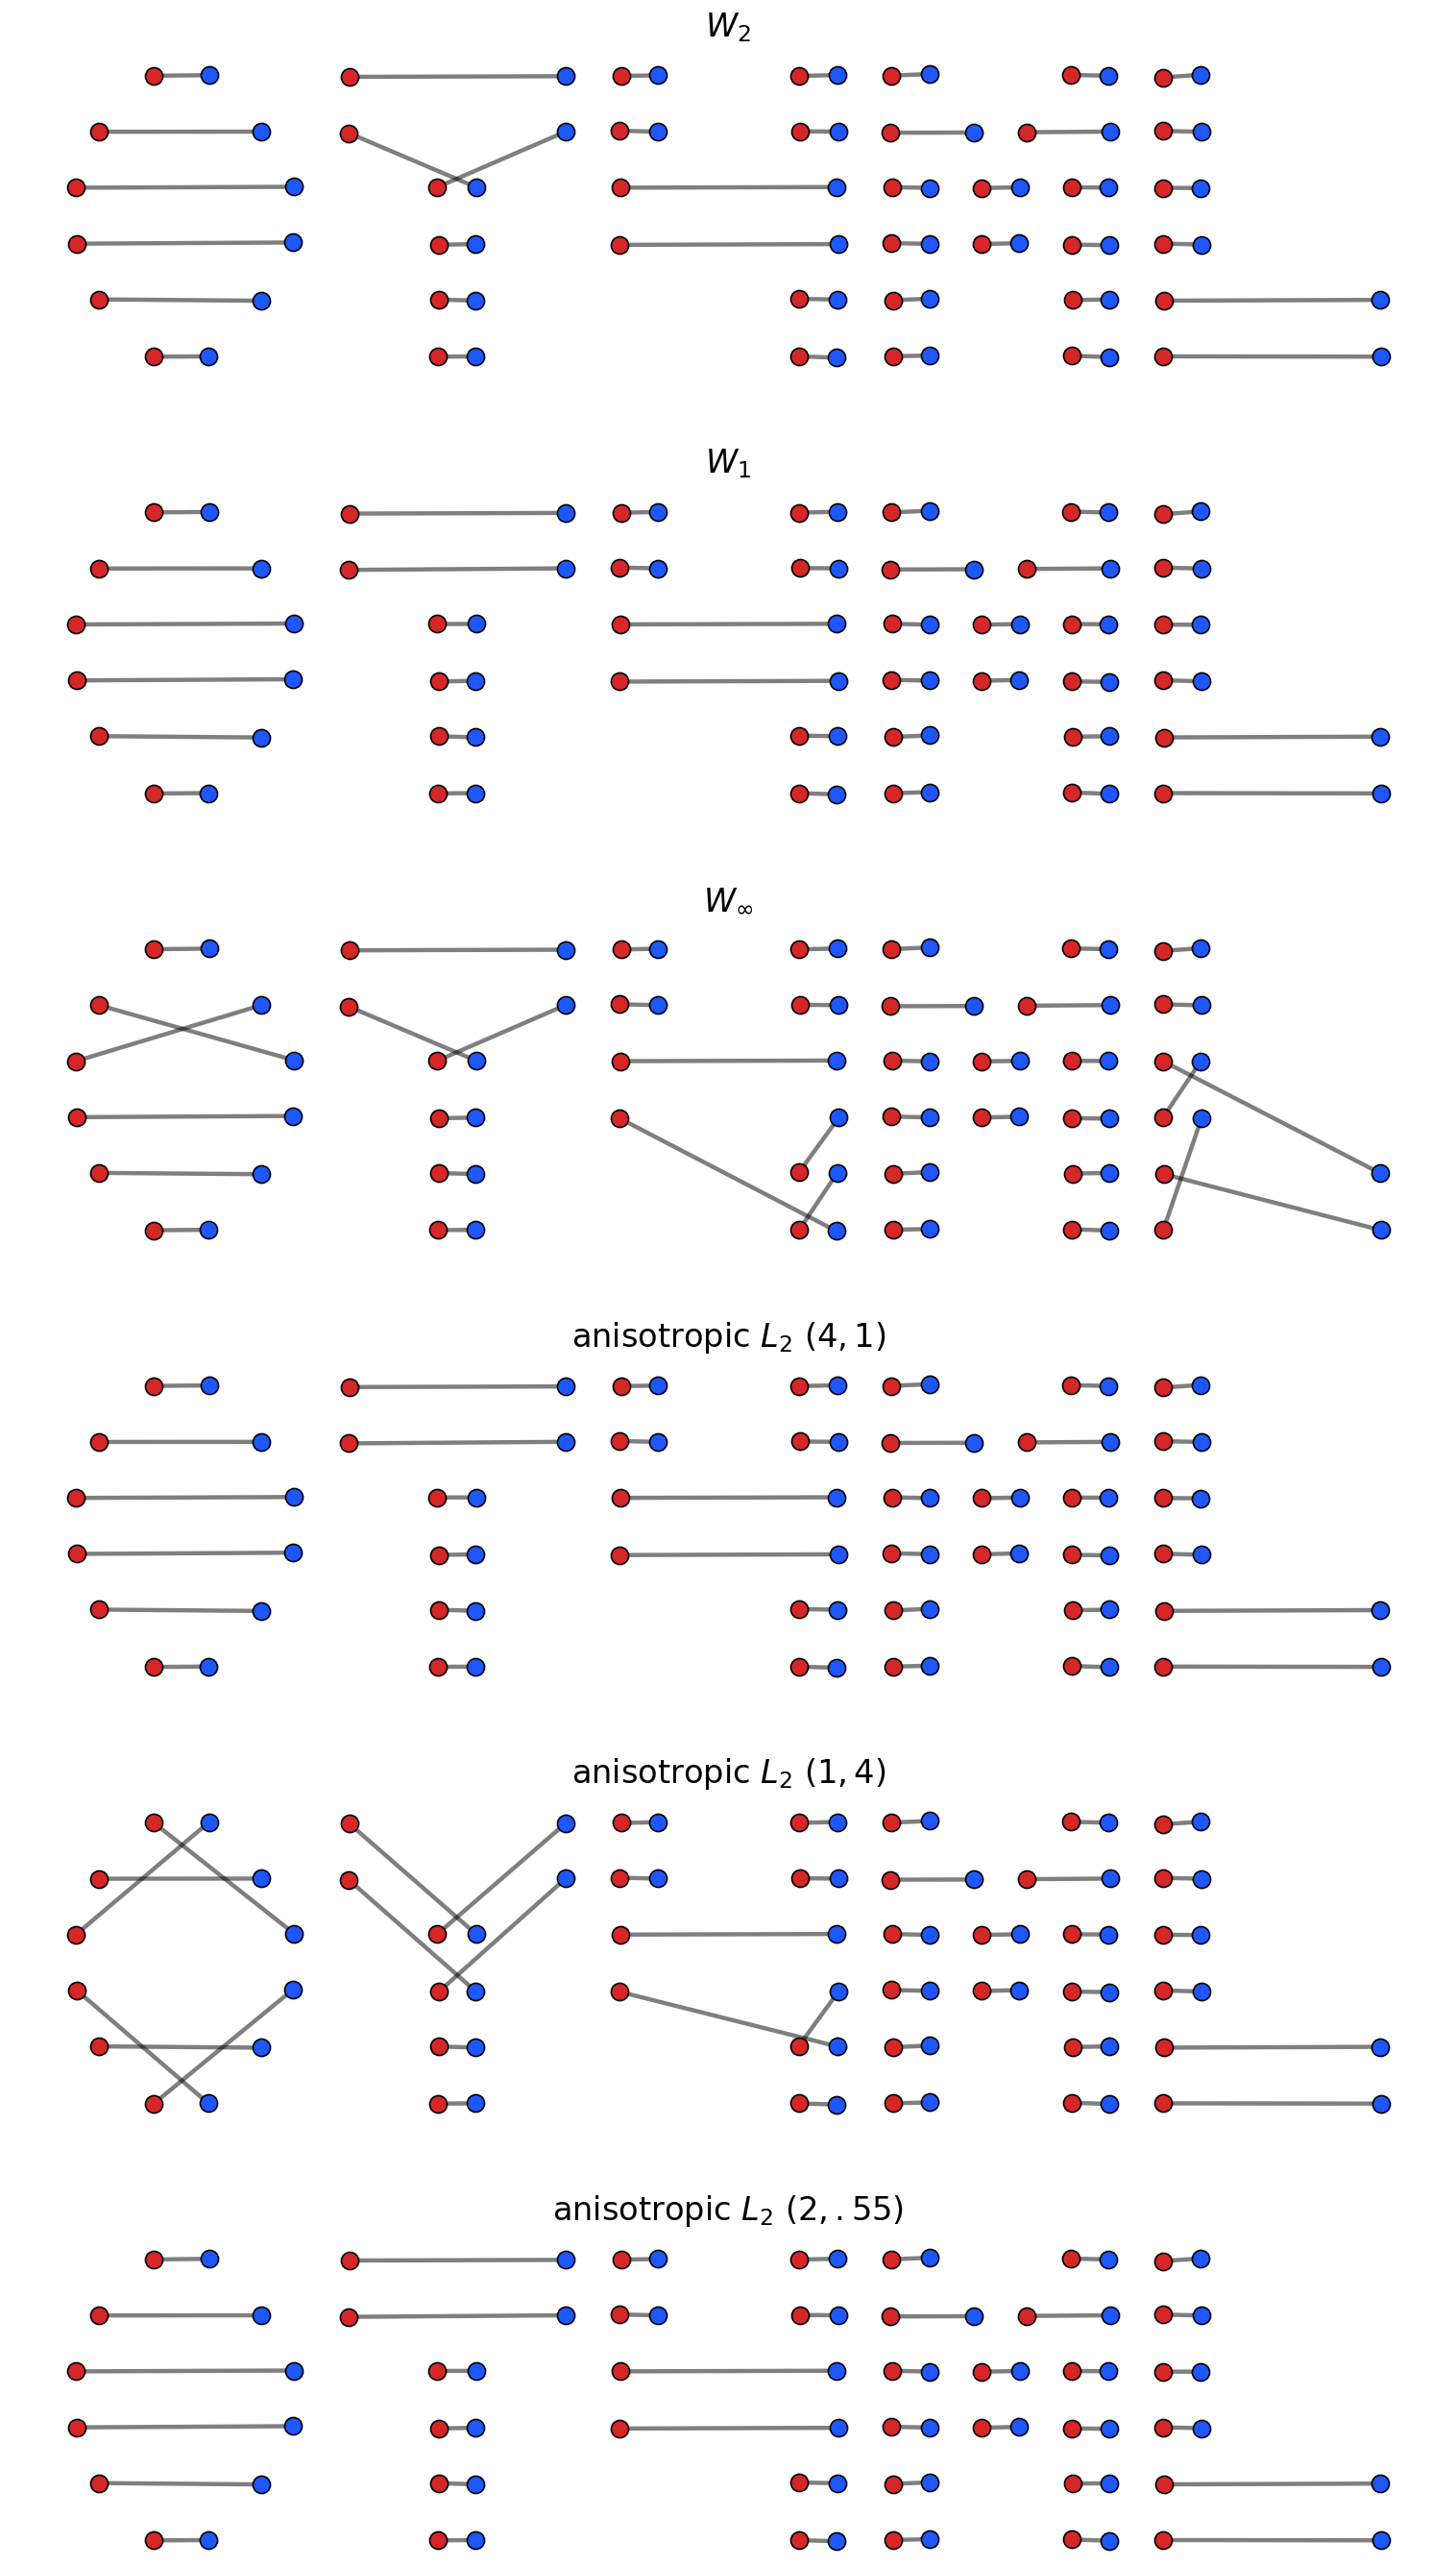

In [5]:
display(Image(filename=str(sheet_png)))

## One-line regeneration

The following command regenerates all exported logo files from a clean kernel.

In [6]:
# generate_all(OUTPUT_DIR)